In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import anndata as ad
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import os
import seaborn as sns
from itertools import combinations
from scipy.stats import kruskal, ttest_ind, ttest_rel, spearmanr, mannwhitneyu
import scikit_posthocs as sp
from sklearn.metrics import r2_score
import json

In [2]:
extension = 'svg'
save_path = f'/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/paper/plots/figures/figure_1/{extension}/'
save_path_supp = f'/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/paper/plots/figures/suppl_figure_1/{extension}/'
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
adata = ad.read_h5ad("/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/results/standard/adatas/cells_final.h5ad")
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/neighborhood_color_map.json', 'r') as f:
    neighborhood_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/phenotype_color_map.json', 'r') as f:
    phenotype_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/disease_color_map.json', 'r') as f:
    disease_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/disease3_color_map.json', 'r') as f:
    disease3_color_map = json.load(f)
neighborhood_colors = [neighborhood_color_map[cat] for cat in list(adata.obs['cellcharter_CN'].cat.categories)]
neighborhood_colors = ListedColormap(neighborhood_colors)
phenotype_colors = [phenotype_color_map[cat] for cat in list(adata.obs['Phenotype4'].cat.categories)]
phenotype_colors = ListedColormap(phenotype_colors)
disease_colors = [disease_color_map[cat] for cat in list(adata.obs['disease2'].cat.categories)]
disease_colors = ListedColormap(disease_colors)
disease3_colors = [disease3_color_map[cat] for cat in list(adata.obs['disease3'].cat.categories)]
disease3_colors = ListedColormap(disease3_colors)

# Supplement

In [ ]:
fig = sc.pl.matrixplot(
        adata, 
        var_names=adata.var_names, 
        groupby='Phenotype4', 
        cmap="coolwarm",
        layer='arcsinh',
        standard_scale="var",
        use_raw=False,
        show=False,
        return_fig=True,)
fig.add_totals()
axes = fig.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
    text.set_fontsize(12)
    current_pos = text.get_position()
    text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax_current_pos = cax.get_position()
cax.set_position((cax_current_pos.x0 - 0.05, cax_current_pos.y0 -0.1, cax_current_pos.width, cax_current_pos.height))
fig = axes['mainplot_ax'].figure
fig.tight_layout()
plt.tight_layout()
fig.savefig(os.path.join(save_path_supp, f"phenotype_matrixplot.{extension}"), bbox_inches='tight')

# C

In [ ]:
fig = sc.pl.matrixplot(
        adata, 
        var_names=['CD38', 'Perilipin', 'MPO', 'CathepsinK', 'RUNX2', 'CD11b', 'CD45', 'CD11c', 'CD4', 'CD34', 'CD68', 'CD8', 'IRF4', 'CD3', 'HLA-DR', 'CD138', 'CollagenTypeI'], 
        groupby='Phenotype4', 
        cmap="coolwarm",
        layer='arcsinh',
        standard_scale="var",
        use_raw=False,
        show=False,
        return_fig=True,)
fig.add_totals()
axes = fig.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
    text.set_fontsize(12)
    current_pos = text.get_position()
    text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax_current_pos = cax.get_position()
cax.set_position((cax_current_pos.x0 - 0.06, cax_current_pos.y0 -0.1, cax_current_pos.width, cax_current_pos.height))
fig = axes['mainplot_ax'].figure
fig.tight_layout()
plt.tight_layout()
fig.savefig(os.path.join(save_path, f"phenotype_matrixplot_selected_markers.{extension}"), bbox_inches='tight')

# B

## See custom_plotting.ipynb

# D

In [ ]:
df = pd.crosstab(
    index=adata.obs['disease3'],
    columns=adata.obs['Phenotype4'],
    normalize='index'
)
df
plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 3))
df_reindexed = df.reindex(['MM', 'SMM', 'MGUS'])
df_reindexed.plot(kind='barh', stacked=True, colormap=phenotype_colors, width = 0.9, ax=ax, legend=False)
ax.set_ylabel('')
ax.set_xlabel('Fraction of cells', fontsize=14)
ax.set_yticklabels(['MM', 'SMM', 'MGUS'], fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
#ax.legend(title='Phenotype', framealpha=0, fontsize=12, title_fontsize=14, bbox_to_anchor=(1, 1.04))
plt.tight_layout()
fig.savefig(os.path.join(save_path, f"phenotype_barplot.{extension}"))


In [ ]:
df = pd.crosstab(
    index=[adata.obs['patient_ID'], adata.obs['disease3']],
    columns=adata.obs['Phenotype4'],
    normalize='index'
)
df = df.reindex(['MM', 'SMM', 'MGUS'], level=1)
df = df.sort_index(level=1, key=lambda x: pd.Categorical(x, categories=['MGUS', 'SMM', 'MM'], ordered=True))
df

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
disease_labels = df.index.get_level_values('disease3')
disease_colors = [disease3_color_map[d] for d in disease_labels]

# Main plot
df.plot(kind='barh', stacked=True, colormap=phenotype_colors, width=1, ax=ax)
ax.xaxis.grid(False)  # Explicit x-axis grid removal
ax.yaxis.grid(False)
ax.set_ylabel('')
ax.set_xlabel('Fraction of cells', fontsize=14)
ax.set_yticklabels('')
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
ax.set_xlim(0, 1)

pos = ax.get_position()
pad = 0.001  
cbar_width = 0.01  

pos = ax.get_position()
ax_disease = fig.add_axes([
    pos.x1 + pad,
    pos.y0,
    cbar_width,
    pos.height
]) 


n_patients = len(df)
disease_colors_array = np.array(disease_colors).reshape(n_patients, 1, 3)
ax_disease.imshow(disease_colors_array, 
                aspect='auto', 
                extent=[0, 1, -0.5, n_patients-0.5], 
                origin='lower')

ax_disease.set_xticks([])
ax_disease.set_yticks([])
ax_disease.set_xticklabels([])
ax_disease.set_yticklabels([])

disease_handles = [
    mpatches.Patch(facecolor=color, label=disease)
    for disease, color in disease3_color_map.items()
]


disease_legend = ax.legend(
    handles=disease_handles,
    title='Disease',
    title_fontsize=14,
    loc='upper left',
    framealpha=0,
    bbox_to_anchor=(1.03, 1.022),  
    fontsize=12)
ax.add_artist(disease_legend)
ax.legend(title='Phenotype', loc='upper left', framealpha=0, bbox_to_anchor=(1.03, 0.73), fontsize=12, title_fontsize=14)
ax_disease.set_axis_off()
fig.savefig(os.path.join(save_path, f"phenotype_barplot_patients.{extension}"), bbox_inches='tight')

# F

In [ ]:
roi_df = pd.crosstab(
    index=[adata.obs['patient_ID'], adata.obs['ROI']],
    columns=adata.obs['Phenotype4'],
    normalize='index'
)
roi_df = roi_df.reset_index()
roi_df

In [ ]:
correlation_results = []

# Group by patient_ID
for patient_id, group in roi_df.groupby('patient_ID'):
    if len(group) > 1:  # Only process patients with more than one ROI
        rois = group.set_index('ROI').iloc[:, 1:]  # Drop patient_ID and keep phenotype frequencies
        
        # Compute pairwise correlations for all ROI combinations
        for roi1, roi2 in combinations(rois.index, 2):
            corr, _ = spearmanr(rois.loc[roi1], rois.loc[roi2])
            correlation_results.append({'patient_ID': patient_id, 'ROI1': roi1, 'ROI2': roi2, 'correlation': corr})
correlation_df = pd.DataFrame(correlation_results)

In [ ]:
# Merge correlation data with disease labels
merged_df = pd.merge(
    correlation_df, 
    adata.obs[['patient_ID', 'disease3']].drop_duplicates(), 
    on='patient_ID'
)

# Plot
plt.figure(figsize=(4, 5))
sns.boxplot(x='disease3', y='correlation', data=merged_df, order=['MGUS', 'SMM', 'MM'], palette=disease3_color_map, showcaps=False, linewidth=2, width=0.75)
#sns.stripplot(x='disease3', y='correlation', data=merged_df, color='black', alpha=0.5)
plt.xlabel('')
ax = plt.gca()
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
plt.ylabel('Spearman Correlation', fontsize=14)
plt.title("ROI Correlation per patient", fontsize=16)
plt.savefig(os.path.join(save_path, f"roi_correlation.{extension}"))


# Supplement

In [ ]:
df = pd.crosstab(
    index=[adata.obs['patient_ID'], adata.obs['disease3']],
    columns=adata.obs['Phenotype4'],
    normalize='index'
)
df = df.reindex(['MM', 'SMM', 'MGUS'], level=1)
df = df.sort_index(level=1, key=lambda x: pd.Categorical(x, categories=['MGUS', 'SMM', 'MM'], ordered=True))
df

In [ ]:
df = df.reset_index()
df = df[[col for col in df.columns if col in ['patient_ID', 'disease3', 'PCs']]]
df

In [ ]:
fig, ax = plt.subplots(figsize=(4, 5))
sns.boxplot(data=df, x='disease3', y='PCs', palette=disease3_color_map, showcaps=False, linewidth=2, width=0.75)
plt.xlabel('')
plt.ylabel('Fraction of PCs', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f"pc_boxplot.{extension}"), bbox_inches='tight')

In [ ]:
groups = [group['PCs'].values for _, group in df.groupby('disease3')]
f_stat, p_val = kruskal(*groups)
print(f"Kruskal-Wallis H-stat: {f_stat:.3f}, p-val: {p_val:.4f}")

In [ ]:
dunn_results = sp.posthoc_dunn(
    df,
    val_col='PCs',
    group_col='disease3',
    p_adjust='bonferroni',
)
print("\nDunn's posthoc results:")
dunn_results

# 2C


In [ ]:
adata2 = ad.read_h5ad("/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/results/standard/adatas/cells_thresholds_scanorama.h5ad")
adata2 = adata2[adata2.obs.index.isin(adata.obs.index)]
adata.obs['Ki67_counts'] = adata2.obs['Ki67_counts'].reindex(adata.obs.index)
adata.obs['proliferating_cells'] =  adata.obs['Phenotype4'].astype(str) + '_' + adata2.obs['Ki67_counts'].astype(str)
# Filter for plasma cells and prepare the dataframe
df = adata[(adata.obs['Phenotype4'] == 'PCs')].obs[['distance_to_bone_corrected', 'disease3', 'image_ID', 'proliferating_cells']]
bins = list(range(0, 601, 20)) #+ list(range(200, 1001, 250)) 
# Bin distances
df['distance_bin'] = pd.cut(df['distance_to_bone_corrected'], bins=bins)

# Group by disease and distance bins
disease_distance_summary = df.groupby(['disease3', 'distance_bin']).apply(
    lambda x: pd.Series({
        'total_cells': len(x),
        'proliferating_cells': (x['proliferating_cells'] == 'PCs_1').sum()
    })
)
disease_distance_summary['proliferating_ratio'] = disease_distance_summary['proliferating_cells'] / disease_distance_summary['total_cells']
disease_distance_summary

In [ ]:
target_col = 'patient_ID'

In [ ]:
disease_mapping = adata.obs[['disease3', target_col]].drop_duplicates()
disease_mapping = disease_mapping.set_index(target_col)
disease_mapping

In [ ]:
adata2 = ad.read_h5ad("/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/results/standard/adatas/cells_thresholds_scanorama.h5ad")
adata2 = adata2[adata2.obs.index.isin(adata.obs.index)]
adata.obs['Ki67_counts'] = adata2.obs['Ki67_counts'].reindex(adata.obs.index)
adata.obs['proliferating_cells'] =  adata.obs['Phenotype4'].astype(str) + '_' + adata2.obs['Ki67_counts'].astype(str)
# Filter for plasma cells and prepare the dataframe
df = adata[(adata.obs['Phenotype4'] == 'PCs')].obs[['distance_to_bone_corrected', 'disease3', target_col, 'proliferating_cells']]
bins = list(range(0, 301, 20)) #+ list(range(200, 1001, 250)) 
# Bin distances
df['distance_bin'] = pd.cut(df['distance_to_bone_corrected'], bins=bins)

# Group by disease and distance bins
disease_distance_summary = df.groupby([target_col, 'distance_bin']).apply(
    lambda x: pd.Series({
        'total_cells': len(x),
        'proliferating_cells': (x['proliferating_cells'] == 'PCs_1').sum()
    })
)
disease_distance_summary['proliferating_ratio'] = disease_distance_summary['proliferating_cells'] / disease_distance_summary['total_cells']
disease_distance_summary.reset_index(inplace=True)
disease_distance_summary

In [ ]:
disease_distance_summary['disease3'] = disease_distance_summary[target_col].map(disease_mapping['disease3'])
disease_distance_summary

In [ ]:
summary_stats = disease_distance_summary.groupby(['distance_bin', 'disease3'], observed=True)['proliferating_ratio'].agg(['mean', 'sem']).reset_index()
summary_stats['distance_bin'] = summary_stats['distance_bin'].astype(str)
summary_stats

In [ ]:
plt.figure(figsize=(10, 6))
plt.style.use('default')
for disease in summary_stats['disease3'].unique():
    subset = summary_stats[summary_stats['disease3'] == disease]
    color = disease3_color_map.get(disease) 
    
    plt.errorbar(
        x=subset['distance_bin'].astype(str),
        y=subset['mean'], 
        yerr=subset['sem'],
        label=disease,
        marker='o', 
        linestyle='-', 
        capsize=5, 
        color=color ,
        linewidth=2,
    )

plt.xticks(rotation=90)
plt.xlabel('Distance interval [µm]', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylabel('Mean Proliferating Ratio', fontsize=14)
plt.title('PCs')
plt.legend(title='', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6) 
plt.tight_layout() 
plt.savefig(os.path.join(save_path, f"mean proliferation_distance_to_bone.{extension}"))

In [ ]:
disease_distance_summary['distance_bin'] = disease_distance_summary['distance_bin'].astype(str)

In [ ]:
zero_twenty = disease_distance_summary[(disease_distance_summary['distance_bin'] == '(0, 20]') & (disease_distance_summary['disease3'] == 'MM')]['proliferating_ratio'].values
twenty_forty = disease_distance_summary[(disease_distance_summary['distance_bin'] == '(20, 40]') & (disease_distance_summary['disease3'] == 'MM')]['proliferating_ratio'].values
forty_sixty = disease_distance_summary[(disease_distance_summary['distance_bin'] == '(40, 60]') & (disease_distance_summary['disease3'] == 'MM')]['proliferating_ratio'].values
sixty_eighty = disease_distance_summary[(disease_distance_summary['distance_bin'] == '(60, 80]') & (disease_distance_summary['disease3'] == 'MM')]['proliferating_ratio'].values
stats, pval = ttest_rel(zero_twenty, twenty_forty, nan_policy='omit')
print(f"t-test between (0, 20] and (20, 40]: t-stat: {stats:.3f}, p-val: {pval:.4f}")
stats, pval = ttest_rel(twenty_forty, forty_sixty, nan_policy='omit')
print(f"t-test between (20, 40] and (40, 60]: t-stat: {stats:.3f}, p-val: {pval:.4f}")
stats, pval = ttest_rel(forty_sixty, sixty_eighty, nan_policy='omit')
print(f"t-test between (40, 60] and (60, 80]: t-stat: {stats:.3f}, p-val: {pval:.4f}")

In [ ]:
zero_twenty = disease_distance_summary[(disease_distance_summary['distance_bin'] == '(0, 20]') & (disease_distance_summary['disease3'] == 'SMM')]['proliferating_ratio'].values
twenty_forty = disease_distance_summary[(disease_distance_summary['distance_bin'] == '(20, 40]') & (disease_distance_summary['disease3'] == 'SMM')]['proliferating_ratio'].values
forty_sixty = disease_distance_summary[(disease_distance_summary['distance_bin'] == '(40, 60]') & (disease_distance_summary['disease3'] == 'SMM')]['proliferating_ratio'].values
sixty_eighty = disease_distance_summary[(disease_distance_summary['distance_bin'] == '(60, 80]') & (disease_distance_summary['disease3'] == 'SMM')]['proliferating_ratio'].values
stats, pval = ttest_rel(zero_twenty, twenty_forty, nan_policy='omit')
print(f"t-test between (0, 20] and (20, 40]: t-stat: {stats:.3f}, p-val: {pval:.4f}")
stats, pval = ttest_rel(twenty_forty, forty_sixty, nan_policy='omit')
print(f"t-test between (20, 40] and (40, 60]: t-stat: {stats:.3f}, p-val: {pval:.4f}")
stats, pval = ttest_rel(forty_sixty, sixty_eighty, nan_policy='omit')
print(f"t-test between (40, 60] and (60, 80]: t-stat: {stats:.3f}, p-val: {pval:.4f}")

In [ ]:
zero_twenty = disease_distance_summary[(disease_distance_summary['distance_bin'] == '(0, 20]') & (disease_distance_summary['disease3'] == 'MGUS')]['proliferating_ratio'].values
twenty_forty = disease_distance_summary[(disease_distance_summary['distance_bin'] == '(20, 40]') & (disease_distance_summary['disease3'] == 'MGUS')]['proliferating_ratio'].values
forty_sixty = disease_distance_summary[(disease_distance_summary['distance_bin'] == '(40, 60]') & (disease_distance_summary['disease3'] == 'MGUS')]['proliferating_ratio'].values
sixty_eighty = disease_distance_summary[(disease_distance_summary['distance_bin'] == '(60, 80]') & (disease_distance_summary['disease3'] == 'MGUS')]['proliferating_ratio'].values
stats, pval = ttest_rel(zero_twenty, twenty_forty, nan_policy='omit')
print(f"t-test between (0, 20] and (20, 40]: t-stat: {stats:.3f}, p-val: {pval:.4f}")
stats, pval = ttest_rel(twenty_forty, forty_sixty, nan_policy='omit')
print(f"t-test between (20, 40] and (40, 60]: t-stat: {stats:.3f}, p-val: {pval:.4f}")
stats, pval = ttest_rel(forty_sixty, sixty_eighty, nan_policy='omit')
print(f"t-test between (40, 60] and (60, 80]: t-stat: {stats:.3f}, p-val: {pval:.4f}")

# 2B

In [ ]:
fig,ax = plt.subplots(figsize=(8, 5))
sc.pl.violin(adata, keys='distance_to_bone_corrected', groupby='Phenotype4', palette=phenotype_color_map, stripplot=False, rotation=90, inner='box', show=False, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('µm', fontsize=14)
ax.set_yticklabels(ax.get_yticks(), fontsize=12)
ax.set_title('Distance to Bone', fontsize=16)
plt.tight_layout()
fig.savefig(os.path.join(save_path, f"distance_to_bone_violin.{extension}"))

# Supplement

In [ ]:
biopsy_pc_fraction = pd.read_excel('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/metadata/percent PCs in biopsies.xlsx')
biopsy_pc_fraction['IMC label'] = biopsy_pc_fraction['IMC label'].astype(str)
biopsy_pc_fraction['IMC label'] = ['IMC' + (x if len(x) >= 2 else '0' + x) for x in biopsy_pc_fraction['IMC label'] if x]
biopsy_pc_fraction.dropna(inplace=True)

In [ ]:
biopsy_pc_fraction.dtypes

In [ ]:
disease_mapping = adata.obs[['patient_ID', 'disease3']].drop_duplicates()
disease_mapping

In [ ]:
df = pd.crosstab(
    index=adata.obs['patient_ID'],
    columns=adata.obs['Phenotype4'],
    normalize='index'
)
df

In [ ]:
biopsy_pc_fraction = biopsy_pc_fraction.merge(
    df['PCs'],
    left_on='IMC label',
    right_index=True,
    how='left'
)
biopsy_pc_fraction['disease3'] = (
    biopsy_pc_fraction['IMC label'].map(disease_mapping.set_index('patient_ID')['disease3'])
)
biopsy_pc_fraction['PCs'] = biopsy_pc_fraction['PCs']*100


In [ ]:
plt.style.use('default')
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x='PCs', y='% PCs from biopsy', hue='disease3', palette=disease3_color_map, data=biopsy_pc_fraction, ax=ax)
sns.regplot(x='PCs', y='% PCs from biopsy', data=biopsy_pc_fraction, scatter=False, color='black', ax=ax)
stat, p = spearmanr(biopsy_pc_fraction['PCs'], biopsy_pc_fraction['% PCs from biopsy'])
r_squared = r2_score(biopsy_pc_fraction['% PCs from biopsy'], biopsy_pc_fraction['PCs'])
ax.text(0.01, 0.90, f'$R^2$ = {r_squared:.2f}\nSpearman $\\rho$ = {stat:.2f}, $p$ = {p:.2e}',transform=ax.transAxes, fontsize=10)
ax.set_xlabel('Fraction of PCs per patient in IMC', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
ax.set_ylabel('% estimated fraction of PCs\nfrom biopsy by pathologist', fontsize=14)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
plt.legend(title='Disease', title_fontsize=14, fontsize=12, loc='lower right')
plt.savefig(os.path.join(save_path_supp, f"biopsy_pc_fraction.{extension}"))

In [ ]:
spearmanr(biopsy_pc_fraction['PCs'], biopsy_pc_fraction['% PCs from biopsy'])

# Supplement

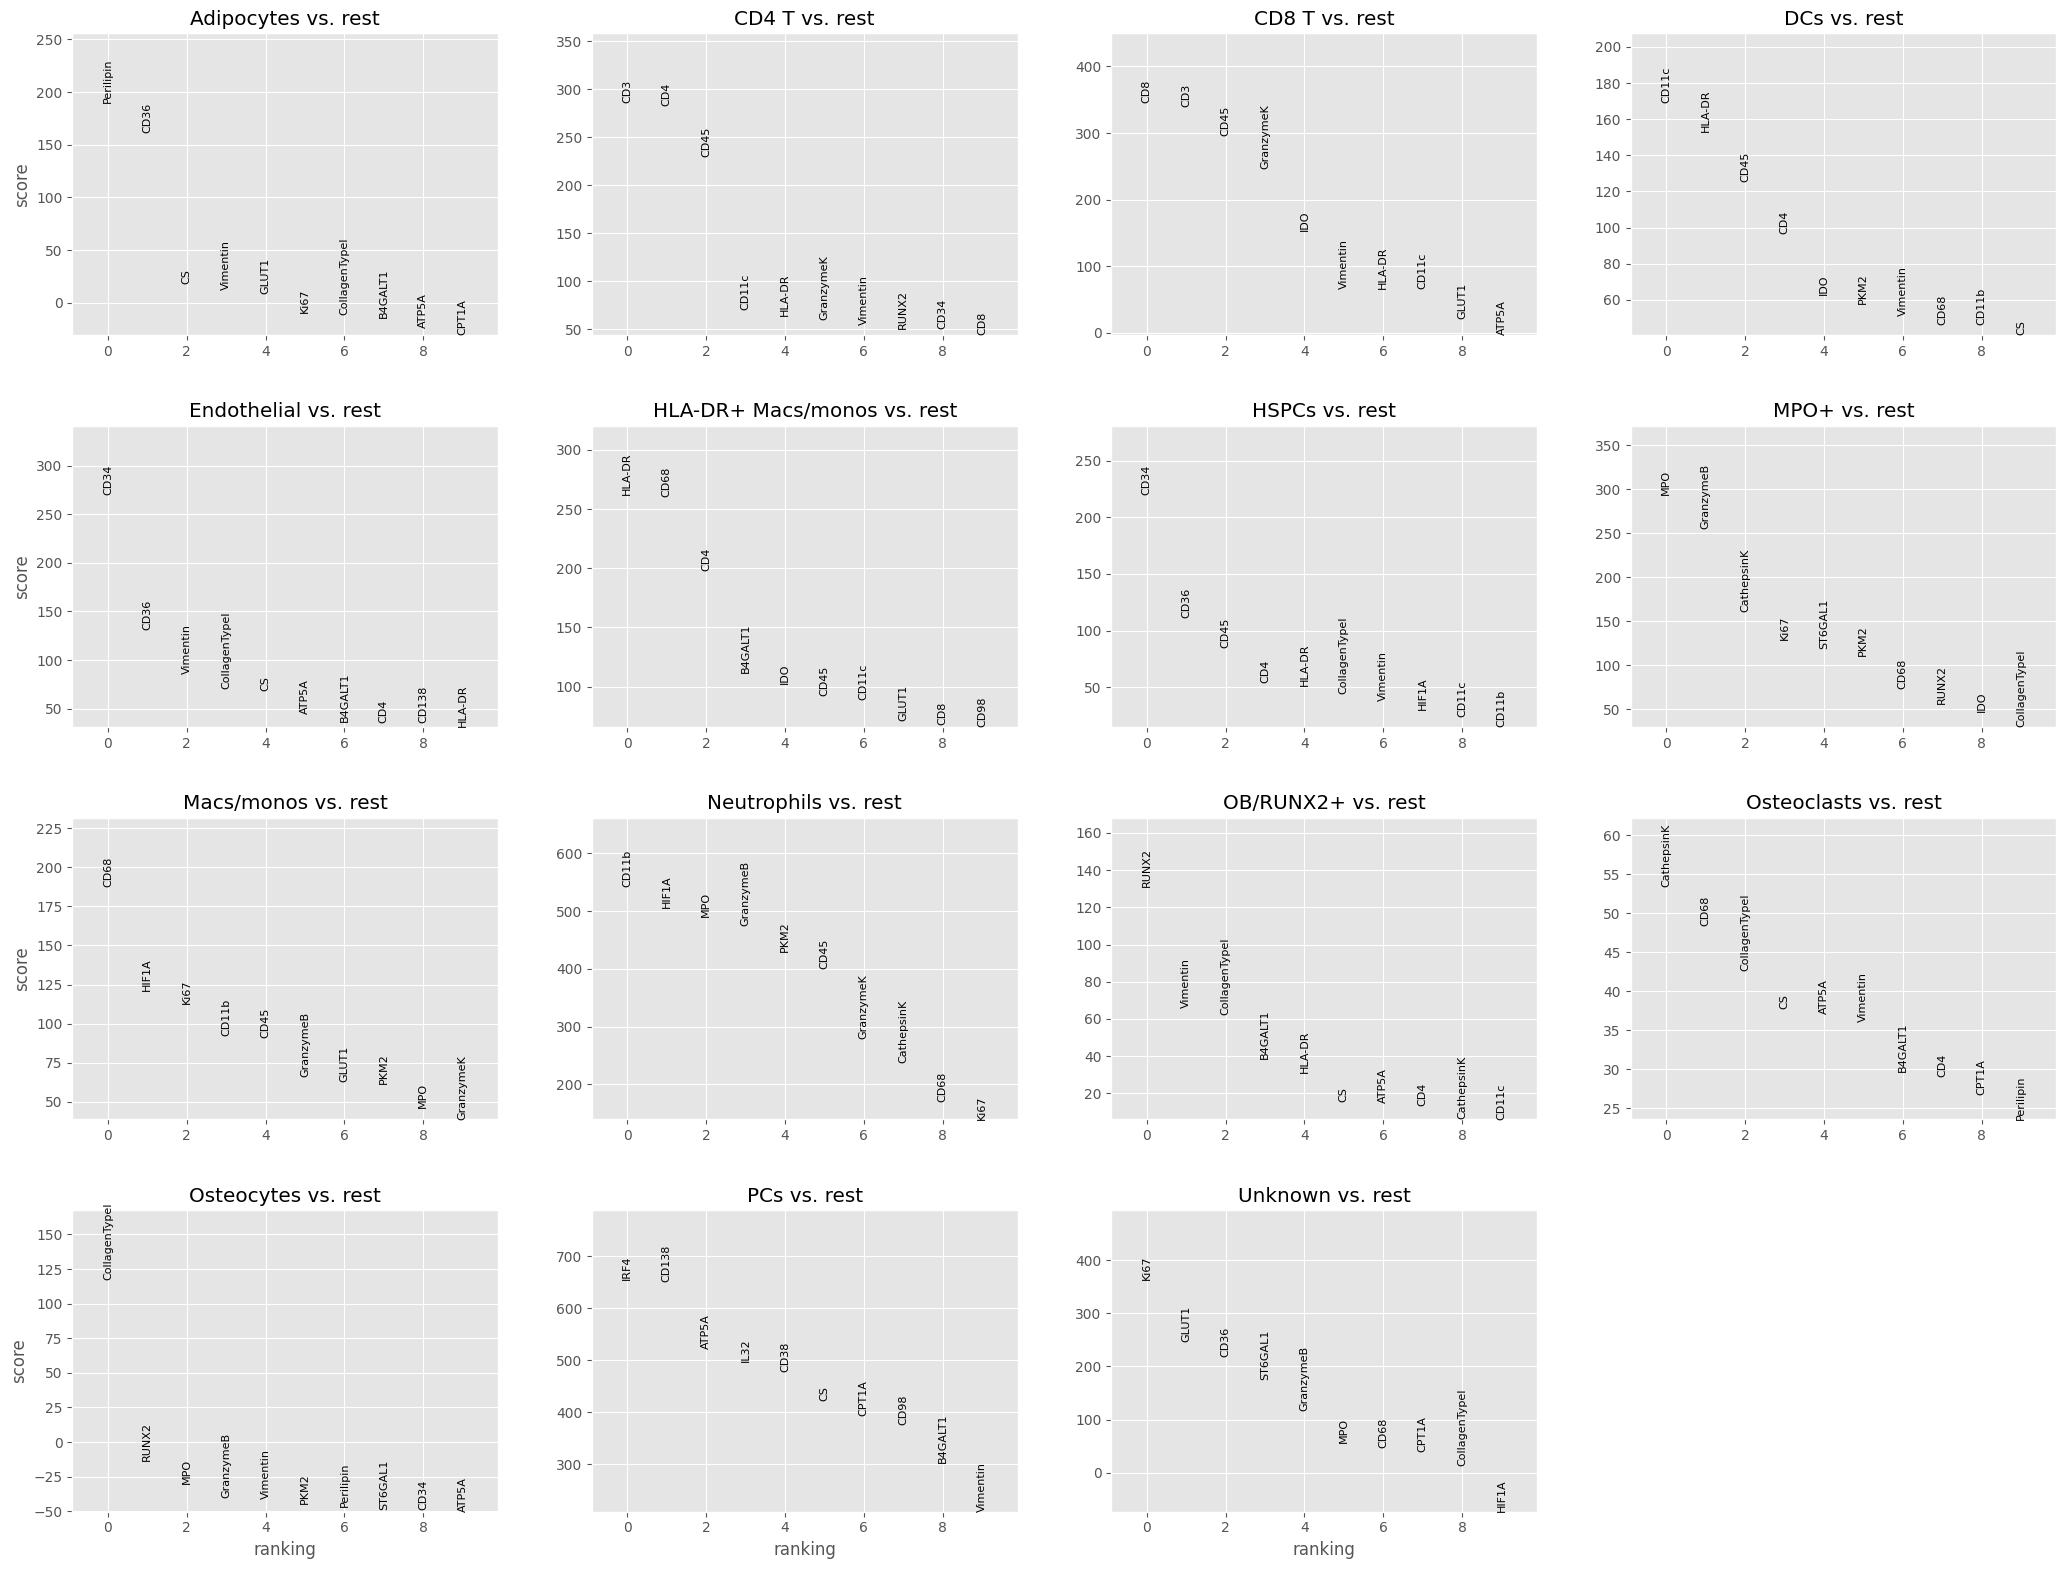

In [3]:
plt.style.use('ggplot')
sc.tl.dendrogram(adata, groupby='Phenotype4')
sc.tl.rank_genes_groups(adata, groupby='Phenotype4', method='wilcoxon', use_raw=False)
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False, show=False, return_fig=True)
fig = plt.gcf()
fig.savefig(os.path.join(save_path_supp, f"phenotype_rank_genes_groups.{extension}"))

In [4]:
df = pd.crosstab(
    index=[adata.obs['patient_ID'], adata.obs['disease3']],
    columns=adata.obs['Phenotype4'],
    normalize='index'
)
df = df.reset_index().melt(id_vars=['patient_ID', 'disease3'], var_name='Phenotype4', value_name='Fraction')


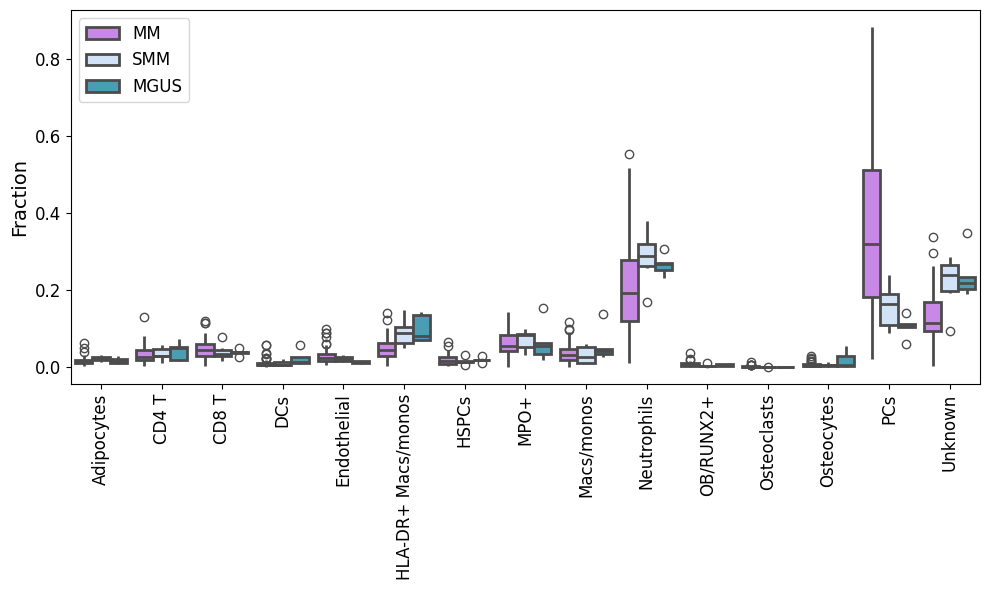

In [5]:
plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='Phenotype4', y='Fraction', hue='disease3', hue_order=['MM', 'SMM','MGUS'], palette=disease3_color_map, showcaps=False, linewidth=2, width=0.85)
plt.xlabel('')
plt.ylabel('Fraction', fontsize=14)
plt.xticks(fontsize=12, rotation=90)
plt.yticks(fontsize=12)
plt.legend(loc='upper left', fontsize=12, title='')
plt.tight_layout()
plt.savefig(os.path.join(save_path_supp, f"phenotype_freqs.{extension}"))

In [6]:
kruskal_dict = {}

for celltype in df['Phenotype4'].unique():
    celltype_df = df[df['Phenotype4'] == celltype]
    groups = [group['Fraction'].values for _, group in celltype_df.groupby('disease3')]
    kruskal_result = kruskal(*groups)
    kruskal_dict[celltype] = {
        'H-statistic': kruskal_result.statistic,
        'p-value': kruskal_result.pvalue
    }
kruskal_dict

/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_61030/2736411282.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group['Fraction'].values for _, group in celltype_df.groupby('disease3')]


{'Adipocytes': {'H-statistic': 5.103007518797, 'p-value': 0.07796433820055416},
 'CD4 T': {'H-statistic': 0.9639465797360742, 'p-value': 0.6175635567484837},
 'CD8 T': {'H-statistic': 1.5291497975708523, 'p-value': 0.4655317870450014},
 'DCs': {'H-statistic': 5.787822703612193, 'p-value': 0.055359259059334885},
 'Endothelial': {'H-statistic': 5.52498554077502,
  'p-value': 0.06313419299489868},
 'HLA-DR+ Macs/monos': {'H-statistic': 15.170292865029722,
  'p-value': 0.0005079404038544746},
 'HSPCs': {'H-statistic': 0.556017666543994, 'p-value': 0.7572901321350732},
 'MPO+': {'H-statistic': 0.6642883432357394, 'p-value': 0.7173838890025984},
 'Macs/monos': {'H-statistic': 1.897165991902824,
  'p-value': 0.3872894255026911},
 'Neutrophils': {'H-statistic': 5.212587412587453,
  'p-value': 0.07380759006212881},
 'OB/RUNX2+': {'H-statistic': 1.3252536936747674,
  'p-value': 0.5154954268588144},
 'Osteoclasts': {'H-statistic': 8.439025611896627,
  'p-value': 0.0147058073417765},
 'Osteocytes'

In [7]:
kruskal_df = pd.DataFrame(kruskal_dict).T
kruskal_df

,H-statistic,p-value
Adipocytes,5.103008,0.077964
CD4 T,0.963947,0.617564
CD8 T,1.529150,0.465532
DCs,5.787823,0.055359
Endothelial,5.524986,0.063134
HLA-DR+ Macs/monos,15.170293,0.000508
HSPCs,0.556018,0.757290
MPO+,0.664288,0.717384
Macs/monos,1.897166,0.387289
Neutrophils,5.212587,0.073808


In [13]:
dunn_dict = {}
for celltype in df['Phenotype4'].unique():
    if kruskal_df.loc[celltype, 'p-value'] < 0.05:   
        celltype_df = df[df['Phenotype4'] == celltype]
        dunn_result = sp.posthoc_dunn(celltype_df, val_col='Fraction', group_col='disease3', p_adjust='bonferroni')
        dunn_dict[celltype] = dunn_result
dunn_dict

{'HLA-DR+ Macs/monos':           MGUS        MM      SMM
 MGUS  1.000000  0.008119  1.00000
 MM    0.008119  1.000000  0.02016
 SMM   1.000000  0.020160  1.00000,
 'Osteoclasts':           MGUS        MM       SMM
 MGUS  1.000000  0.508647  1.000000
 MM    0.508647  1.000000  0.023533
 SMM   1.000000  0.023533  1.000000,
 'PCs':        MGUS        MM       SMM
 MGUS  1.000  0.009000  1.000000
 MM    0.009  1.000000  0.063555
 SMM   1.000  0.063555  1.000000,
 'Unknown':           MGUS        MM       SMM
 MGUS  1.000000  0.012663  1.000000
 MM    0.012663  1.000000  0.032685
 SMM   1.000000  0.032685  1.000000}

In [9]:
dunn_dict['HLA-DR+ Macs/monos']

,MGUS,MM,SMM
MGUS,1.000000,0.008119,1.00000
MM,0.008119,1.000000,0.02016
SMM,1.000000,0.020160,1.00000


In [10]:
dunn_dict['Unknown']

,MGUS,MM,SMM
MGUS,1.000000,0.012663,1.000000
MM,0.012663,1.000000,0.032685
SMM,1.000000,0.032685,1.000000


In [11]:
dunn_dict['PCs']

,MGUS,MM,SMM
MGUS,1.000,0.009000,1.000000
MM,0.009,1.000000,0.063555
SMM,1.000,0.063555,1.000000
